# 🔬 Análise Interativa de Parâmetros (Versão Expert)

Este notebook é uma ferramenta para explorar interativamente o impacto dos parâmetros do ambiente, da função de recompensa e do comportamento detalhado dos agentes treinados.

In [18]:
# Célula 1: Instalação e Importação de Bibliotecas
import ipywidgets as widgets
from ipywidgets import interactive
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import json
import os
import glob
from IPython.display import display, clear_output

try:
    from classroom_ac_env import ClassroomACEnvironment, ClassroomConfig, ACState
    from ac_qlearning_agent import ACQLearningAgent, QLearningConfig
    from ac_dqn_agent import ACDQNAgent, DQNConfig
    from analysis import load_agent_from_results, run_simulation, plot_scenario_dashboard
    print("Módulos do projeto carregados com sucesso!")
except ImportError as e:
    print(f"ERRO ao importar módulos: {e}")

sns.set_theme(style="whitegrid")

Módulos do projeto carregados com sucesso!


## Parte 1: Explorando a Física do Ambiente

In [19]:
# Célula 2: Simulação da Física
def plot_environment_physics(thermal_mass, heat_transfer_coeff, occupancy, ac_action_str, season):
    config = ClassroomConfig(thermal_mass=thermal_mass, heat_transfer_coeff=heat_transfer_coeff, season=season)
    env = ClassroomACEnvironment(config)
    options = {'start_temp': 28.0, 'occupancy': occupancy, 'hour_of_day': 14}
    env.reset(options=options)
    ac_action = ACState[ac_action_str].value
    temps, outdoor_temps = [env.current_temp], [env._calculate_outdoor_temp()]
    for _ in range(120):
        _, _, _, _, info = env.step(ac_action)
        temps.append(info['temperature'])
        outdoor_temps.append(env._calculate_outdoor_temp())
    plt.figure(figsize=(14, 7))
    plt.plot(temps, label='Temperatura Interna', lw=3, color='royalblue')
    plt.plot(outdoor_temps, label='Temperatura Externa', lw=2, color='gray', linestyle='--')
    plt.axhspan(config.temp_comfort_min, config.temp_comfort_max, color='green', alpha=0.15, label='Faixa de Conforto')
    plt.title(f'Resposta da Sala com AC em "{ac_action_str}" e {occupancy} Pessoas', fontsize=16)
    plt.ylabel('Temperatura (°C)'); plt.xlabel('Passos de Tempo (6 min)')
    plt.legend(); plt.ylim(15, 40); plt.grid(True, which='both', linestyle='--'); plt.show()
interactive_plot = interactive(plot_environment_physics, thermal_mass=widgets.FloatSlider(value=1000, min=500, max=5000, step=100, description='Inércia Térmica:'), heat_transfer_coeff=widgets.FloatSlider(value=0.5, min=0.1, max=2.0, step=0.1, description='Coef. de Calor:'), occupancy=widgets.IntSlider(value=30, min=0, max=50, step=1, description='Ocupação:'), ac_action_str=widgets.Dropdown(options=[s.name for s in ACState], value='MEDIUM', description='Ação do AC:'), season=widgets.Dropdown(options=['summer', 'winter'], value='summer', description='Estação:'))
display(interactive_plot)

interactive(children=(FloatSlider(value=1000.0, description='Inércia Térmica:', max=5000.0, min=500.0, step=10…

## Parte 2: Explorando a Função de Recompensa

In [20]:
# Célula 3: Análise de Recompensa
def analyze_reward(comfort_bonus, warm_penalty, energy_penalty_mult, is_peak_hour):
    reward_structure = {'COMFORTABLE': comfort_bonus, 'WARM': warm_penalty}
    config = ClassroomConfig(reward_structure=reward_structure, energy_penalty_multiplier_peak=energy_penalty_mult)
    env = ClassroomACEnvironment(config)
    scenarios = {'Confortável (AC OFF)': {'temp': 24.0, 'ac_state': ACState.OFF}, 'Quente (AC MEDIUM)': {'temp': 28.0, 'ac_state': ACState.MEDIUM}, 'Quente (AC HIGH)': {'temp': 28.0, 'ac_state': ACState.HIGH}}
    print("--- Análise de Recompensa Instantânea ---")
    for name, params in scenarios.items():
        env.current_temp = params['temp']; env.ac_state = params['ac_state']; env.hour_of_day = 19 if is_peak_hour else 14
        comfort_level = env._get_comfort_level()
        comfort_rw = env.config.reward_structure.get(comfort_level.name, 0)
        energy_consumption = env.config.ac_energy_consumption[env.ac_state]
        multiplier = env.config.energy_penalty_multiplier_peak if is_peak_hour else 1.0
        energy_pen = -energy_consumption * 0.1 * multiplier
        total_reward = comfort_rw + energy_pen
        print(f"\nCenário: {name}\n  Bônus/Punição de Conforto: {comfort_rw:.2f}\n  Penalidade de Energia: {energy_pen:.2f}\n  RECOMPENSA TOTAL: {total_reward:.2f}")
interactive_reward_analysis = interactive(analyze_reward, comfort_bonus=widgets.FloatSlider(value=1.0, min=1.0, max=20.0, step=1.0, description='Bônus Conforto:'), warm_penalty=widgets.FloatSlider(value=-5.0, min=-20.0, max=-1.0, step=1.0, description='Punição Calor:'), energy_penalty_mult=widgets.FloatSlider(value=1.5, min=1.0, max=5.0, step=0.5, description='Mult. Pico Energia:'), is_peak_hour=widgets.Checkbox(value=False, description='É Horário de Pico?'))
display(interactive_reward_analysis)

interactive(children=(FloatSlider(value=1.0, description='Bônus Conforto:', max=20.0, min=1.0, step=1.0), Floa…

## Parte 3: Análise de Agentes Treinados (Análise Rápida)
Use a interface abaixo para uma análise visual rápida de um agente em um cenário específico.

In [21]:
# Célula 4: Interface Interativa para Análise Individual
try:
    with open('scenarios.json', 'r') as f: scenarios_list = json.load(f)
    scenario_options = {s['name']: s for s in scenarios_list}
except FileNotFoundError: scenario_options = {'fallback': {'name': 'fallback', 'start_temp': 28.0, 'occupancy': 30, 'hour': 14}}
results_dir_input = widgets.Text(value='results_...', description='Pasta de Resultados:', layout={'width': '400px'})
load_button = widgets.Button(description="Carregar Modelos")
model_dropdown = widgets.Dropdown(description='Agente:')
scenario_dropdown = widgets.Dropdown(options=scenario_options.keys(), description='Cenário:')
output_area = widgets.Output()
loaded_agents = {}
def on_load_button_clicked(b):
    with output_area:
        clear_output(wait=True)
        results_dir = results_dir_input.value
        if not os.path.isdir(results_dir): print(f"Diretório não encontrado: {results_dir}"); return
        print(f"Procurando modelos em '{results_dir}'...")
        json_files = sorted(glob.glob(os.path.join(results_dir, '*_results.json')))
        model_names = [os.path.basename(f).replace('_results.json', '') for f in json_files]
        if not model_names: print("Nenhum arquivo de resultado encontrado."); return
        loaded_agents.clear()
        for name in model_names:
            display_name = name.replace('_', ' ').title()
            result = load_agent_from_results(results_dir, name)
            if result: loaded_agents[display_name] = result
        model_dropdown.options = loaded_agents.keys()
        print(f"Modelos carregados com sucesso: {list(loaded_agents.keys())}")
def on_value_change(change):
    with output_area:
        if not change['new'] or not model_dropdown.value or not scenario_dropdown.value: return
        clear_output(wait=True); print("Gerando simulação...")
        model_display_name = model_dropdown.value
        agent, env_config, _ = loaded_agents[model_display_name]
        scenario_name = scenario_dropdown.value
        scenario_params = scenario_options[scenario_name]
        env = ClassroomACEnvironment(env_config)
        df_result = run_simulation(agent, env, scenario_params)
        # Reutiliza a função de plotagem do analyzer (que foi importada)
        plot_scenario_dashboard(model_display_name, {scenario_name: df_result}, env, ".")
        print("Simulação concluída.")
load_button.on_click(on_load_button_clicked)
model_dropdown.observe(on_value_change, names='value')
scenario_dropdown.observe(on_value_change, names='value')
display(widgets.VBox([widgets.HBox([results_dir_input, load_button]), widgets.HBox([model_dropdown, scenario_dropdown]), output_area]))

---

## Parte 4: Análise Aprofundada e Comparativa (Expert)

As células a seguir realizam uma análise quantitativa e comparativa de **todos os agentes carregados** em **todos os cenários**. Execute-as após carregar os modelos na Parte 3.

In [22]:
# Célula 5: Agregação de Dados para Análise Comparativa
if not loaded_agents:
    print("ERRO: Nenhum agente carregado. Execute a Célula 4 primeiro.")
else:
    all_results_list = []
    print("Iniciando simulação de todos os cenários para todos os agentes...")
    for model_name, (agent, env_config, _) in loaded_agents.items():
        print(f"  -> Simulando agente: {model_name}...")
        env = ClassroomACEnvironment(env_config)
        for scenario_name, scenario_params in scenario_options.items():
            df_result = run_simulation(agent, env, scenario_params)
            df_result['agent'] = model_name; df_result['scenario'] = scenario_name
            all_results_list.append(df_result)
    df_full = pd.concat(all_results_list, ignore_index=True)
    action_map = {state.value: state.name for state in ACState}
    df_full['ac_action_name'] = df_full['ac_action'].map(action_map)
    print("\n✅ Agregação de dados concluída. DataFrame 'df_full' está pronto para as próximas análises.")
df_full.head()

ERRO: Nenhum agente carregado. Execute a Célula 4 primeiro.


,step,temperature,ac_action,comfort,energy,reward,agent,scenario,ac_action_name
0,0,18.979528,1,0,1.5,-7.15,Dqn Baseline,"1: ManhÃ£ Fria, Sala Vazia",LOW
1,1,19.048798,1,0,1.5,-5.15,Dqn Baseline,"1: ManhÃ£ Fria, Sala Vazia",LOW
2,2,19.021068,1,0,1.5,-5.15,Dqn Baseline,"1: ManhÃ£ Fria, Sala Vazia",LOW
3,3,19.087108,1,0,1.5,-5.15,Dqn Baseline,"1: ManhÃ£ Fria, Sala Vazia",LOW
4,4,18.935897,1,0,1.5,-5.15,Dqn Baseline,"1: ManhÃ£ Fria, Sala Vazia",LOW


### Análise 4.1: Tabela de Estatísticas Descritivas
Esta tabela mostra um resumo estatístico completo (média, desvio padrão, quartis, etc.) para as métricas chave em cada cenário. Isso nos permite ver não apenas a performance média, mas também a sua consistência.

In [23]:
# Célula 6: Tabela de Estatísticas Detalhadas
if 'df_full' in locals():
    # Cria uma tabela pivô com múltiplas estatísticas
    pd.set_option('display.max_rows', 100) # Permite ver mais linhas
    detailed_summary = df_full.groupby(['scenario', 'agent']).agg(
        temp_media=('temperature', 'mean'),
        temp_std=('temperature', 'std'),
        energia_total=('energy', lambda x: (x*0.1).sum()),
        recompensa_media=('reward', 'mean'),
        recompensa_acumulada=('reward', 'sum')
    ).round(2)
    
    display(detailed_summary)
else:
    print("Execute a célula de agregação de dados primeiro.")

temp_media  \
scenario                                agent                                       
1: ManhÃ£ Fria, Sala Vazia              Dqn Baseline                        18.17   
                                        Dqn Foco Alto Em Conforto           19.65   
                                        Dqn Foco Moderado Em Conforto       21.18   
                                        Dqn Tolerância Zero                 18.62   
2: ManhÃ£ AgradÃ¡vel, Sala Enchendo     Dqn Baseline                        24.45   
                                        Dqn Foco Alto Em Conforto           23.82   
                                        Dqn Foco Moderado Em Conforto       22.70   
                                        Dqn Tolerância Zero                 23.53   
3: Tarde Quente, Sala Cheia             Dqn Baseline                        27.38   
                                        Dqn Foco Alto Em Conforto           27.86   
                                        Dqn Foco Moderado Em Conforto       28.34   
                                        Dqn Tolerância Zero                 28.30   
4: Tarde Quente, Sala Superlotada       Dqn Baseline                        30.13   
                                        Dqn Foco Alto Em Conforto           28.69   
                                        Dqn Foco Moderado Em Conforto       28.83   
                                        Dqn Tolerância Zero                 29.60   
5: Fim de Tarde, Sala Esvaziando        Dqn Baseline                        24.97   
                                        Dqn Foco Alto Em Conforto           26.22   
                                        Dqn Foco Moderado Em Conforto       24.87   
                                        Dqn Tolerância Zero                 25.88   
6: Noite, Sala Vazia (HorÃ¡rio de Pico) Dqn Baseline                        23.71   
                                        Dqn Foco Alto Em Conforto           24.98   
                                        Dqn Foco Moderado Em Conforto       24.70   
                                        Dqn Tolerância Zero                 24.50   
7: Onda de Calor Extrema (Estresse)     Dqn Baseline                        32.21   
                                        Dqn Foco Alto Em Conforto           31.67   
                                        Dqn Foco Moderado Em Conforto       32.04   
                                        Dqn Tolerância Zero                 31.95   
8: Inverno HipotÃ©tico (InaÃ§Ã£o)       Dqn Baseline                        11.90   
                                        Dqn Foco Alto Em Conforto           13.14   
                                        Dqn Foco Moderado Em Conforto       11.79   
                                        Dqn Tolerância Zero                 11.05   

                                                                       temp_std  \
scenario                                agent                                     
1: ManhÃ£ Fria, Sala Vazia              Dqn Baseline                       0.27   
                                        Dqn Foco Alto Em Conforto          0.35   
                                        Dqn Foco Moderado Em Conforto      1.00   
                                        Dqn Tolerância Zero                0.32   
2: ManhÃ£ AgradÃ¡vel, Sala Enchendo     Dqn Baseline                       0.65   
                                        Dqn Foco Alto Em Conforto          0.54   
                                        Dqn Foco Moderado Em Conforto      0.41   
                                        Dqn Tolerância Zero                0.45   
3: Tarde Quente, Sala Cheia             Dqn Baseline                       0.38   
                                        Dqn Foco Alto Em Conforto          0.29   
                                        Dqn Foco Moderado Em Conforto      0.26   
                                        Dqn Tolerância Zero                0.23   
4: Tarde Quente, S

### Análise 4.2: Acúmulo de Recompensa em Cenário de Estresse
Este gráfico mostra como a "pontuação" de cada agente evolui ao longo do tempo no cenário mais desafiador. Um agente superior terá uma curva que sobe (ou desce menos) que as outras.

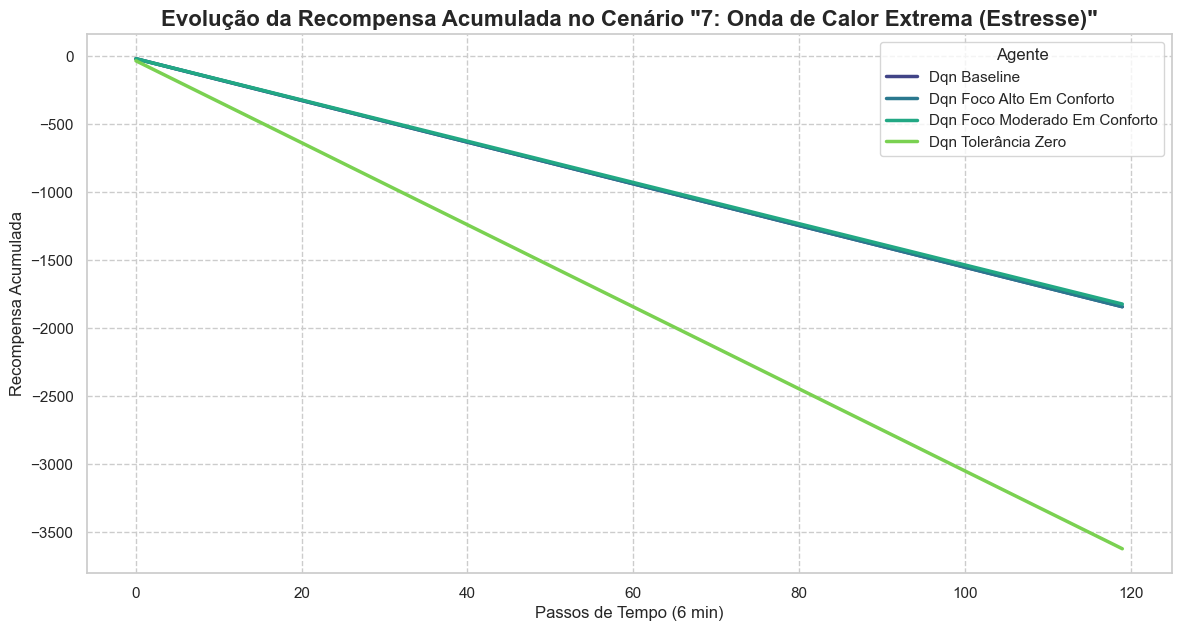

In [24]:
# Célula 7: Evolução da Recompensa Acumulada
if 'df_full' in locals():
    stress_scenario_name = '7: Onda de Calor Extrema (Estresse)'
    df_stress = df_full[df_full['scenario'] == stress_scenario_name].copy()
    
    # Calcula a recompensa acumulada para cada agente
    df_stress['cumulative_reward'] = df_stress.groupby('agent')['reward'].cumsum()
    
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=df_stress, x='step', y='cumulative_reward', hue='agent', lw=2.5, palette='viridis')
    
    plt.title(f'Evolução da Recompensa Acumulada no Cenário "{stress_scenario_name}"', fontsize=16, weight='bold')
    plt.ylabel('Recompensa Acumulada')
    plt.xlabel('Passos de Tempo (6 min)')
    plt.grid(True, which='both', linestyle='--')
    plt.legend(title='Agente')
    plt.show()
else:
    print("Execute a célula de agregação de dados primeiro.")

### Análise 4.3: Tempo até o Conforto e Estabilidade da Política
Estas métricas quantificam a **agilidade** e a **calma** de cada agente.
- **Tempo até Conforto:** Quantos minutos o agente leva para trazer a temperatura para a faixa ideal em um cenário quente (menor é melhor).
- **Mudanças de Ação:** Quantas vezes o agente muda a potência do AC. Um número baixo indica uma política estável (geralmente melhor).

C:\Users\engre\AppData\Local\Temp\ipykernel_25712\2881436669.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  advanced_metrics = df_full[df_full['scenario'] == stress_scenario_name].groupby('agent').apply(calculate_metrics)
C:\Users\engre\AppData\Local\Temp\ipykernel_25712\2881436669.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=advanced_metrics.sort_values('time_to_comfort_min'), x=advanced_metrics.index, y='time_to_comfort_min', ax=ax1, palette='coolwarm')
C:\Users\engre\AppData\Local\Temp\ipykernel_25712\2881436669.py:25: FutureWarnin

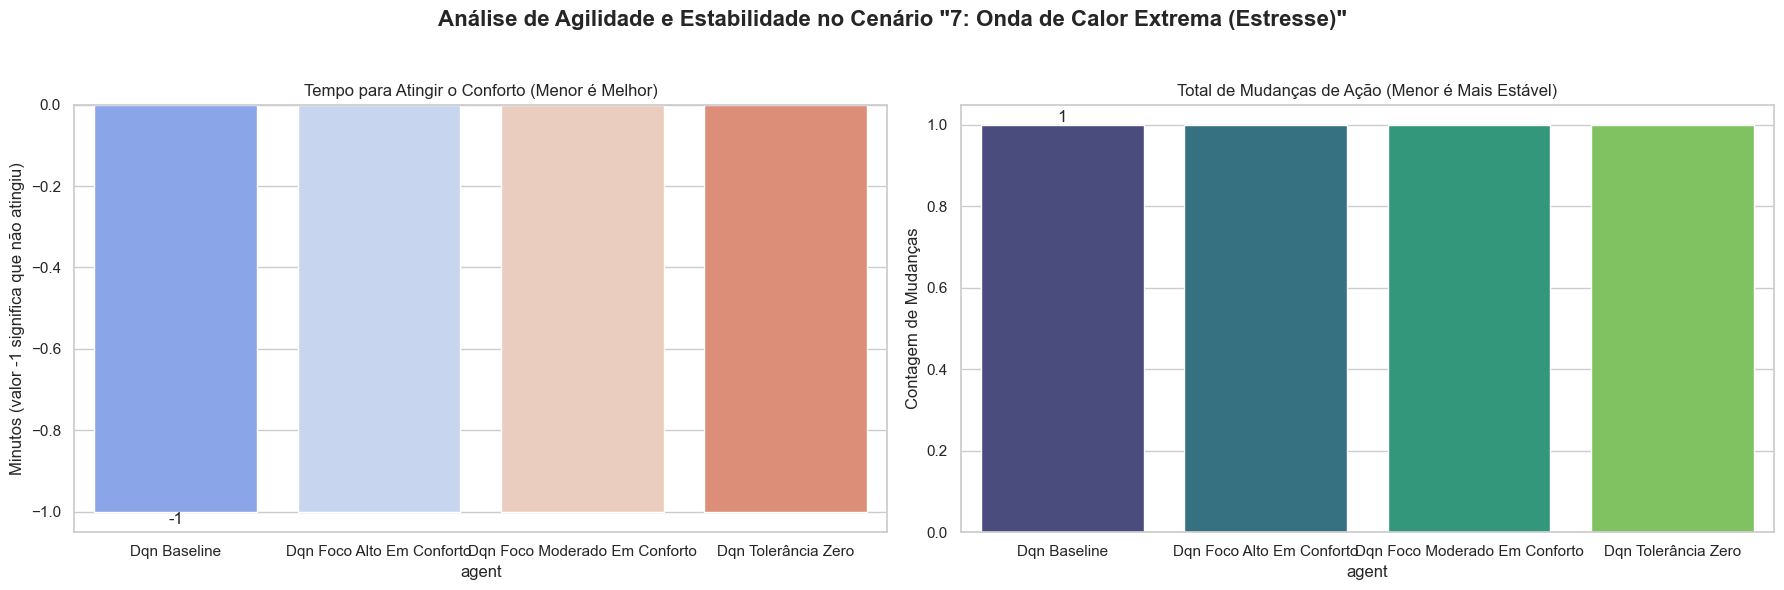

In [25]:
# Célula 8: Cálculo de Métricas de Agilidade e Estabilidade
if 'df_full' in locals():
    def calculate_metrics(df_group):
        # Tempo até o primeiro passo confortável
        first_comfort_step = df_group[df_group['comfort'] == 1]['step'].min()
        time_to_comfort = first_comfort_step * 6 if pd.notna(first_comfort_step) else -1 # em minutos
        
        # Contagem de mudanças de ação
        action_changes = (df_group['ac_action'].diff() != 0).sum()
        
        return pd.Series({'time_to_comfort_min': time_to_comfort, 'action_changes': action_changes})

    # Aplica o cálculo apenas ao cenário de estresse
    stress_scenario_name = '7: Onda de Calor Extrema (Estresse)'
    advanced_metrics = df_full[df_full['scenario'] == stress_scenario_name].groupby('agent').apply(calculate_metrics)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle(f'Análise de Agilidade e Estabilidade no Cenário "{stress_scenario_name}"', fontsize=16, weight='bold')
    
    sns.barplot(data=advanced_metrics.sort_values('time_to_comfort_min'), x=advanced_metrics.index, y='time_to_comfort_min', ax=ax1, palette='coolwarm')
    ax1.set_title('Tempo para Atingir o Conforto (Menor é Melhor)')
    ax1.set_ylabel('Minutos (valor -1 significa que não atingiu)')
    ax1.bar_label(ax1.containers[0])
    
    sns.barplot(data=advanced_metrics.sort_values('action_changes'), x=advanced_metrics.index, y='action_changes', ax=ax2, palette='viridis')
    ax2.set_title('Total de Mudanças de Ação (Menor é Mais Estável)')
    ax2.set_ylabel('Contagem de Mudanças')
    ax2.bar_label(ax2.containers[0])
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
else:
    print("Execute a célula de agregação de dados primeiro.")

### Análise 4.4: Comparação Direta de Controle de Temperatura
Por fim, vamos sobrepor as curvas de temperatura de todos os agentes em um único gráfico para os cenários mais importantes. Isso permite uma comparação visual direta de suas estratégias de controle.

Gerando gráficos de comparação direta de temperatura...


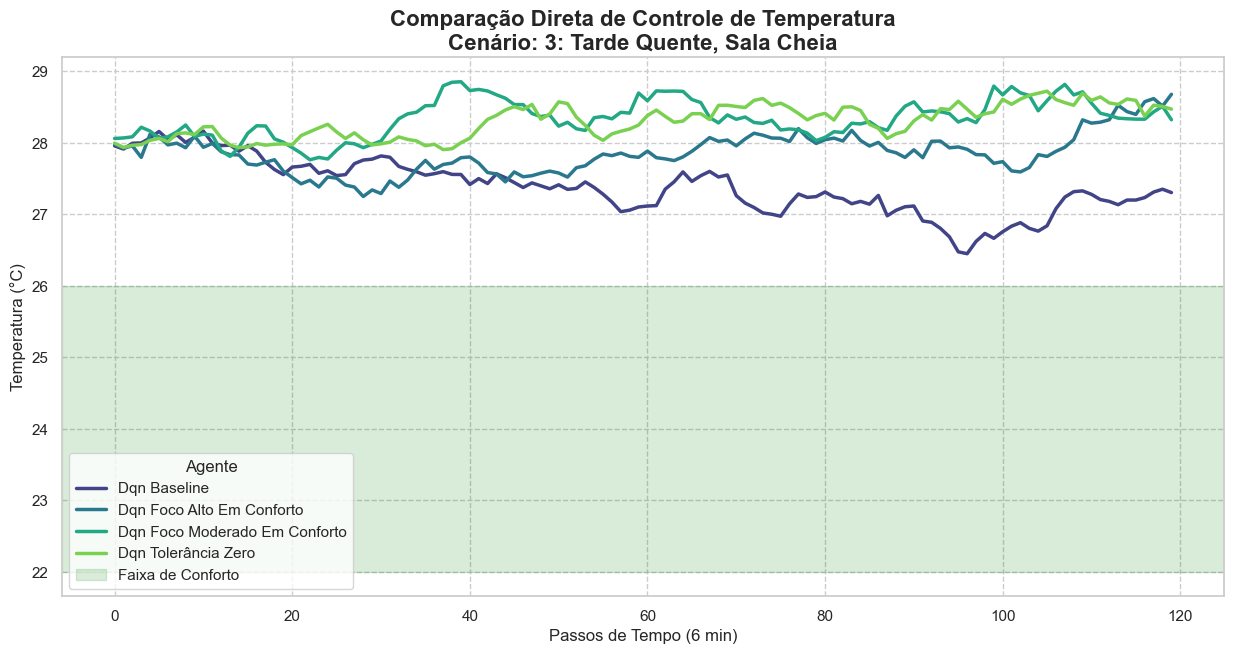

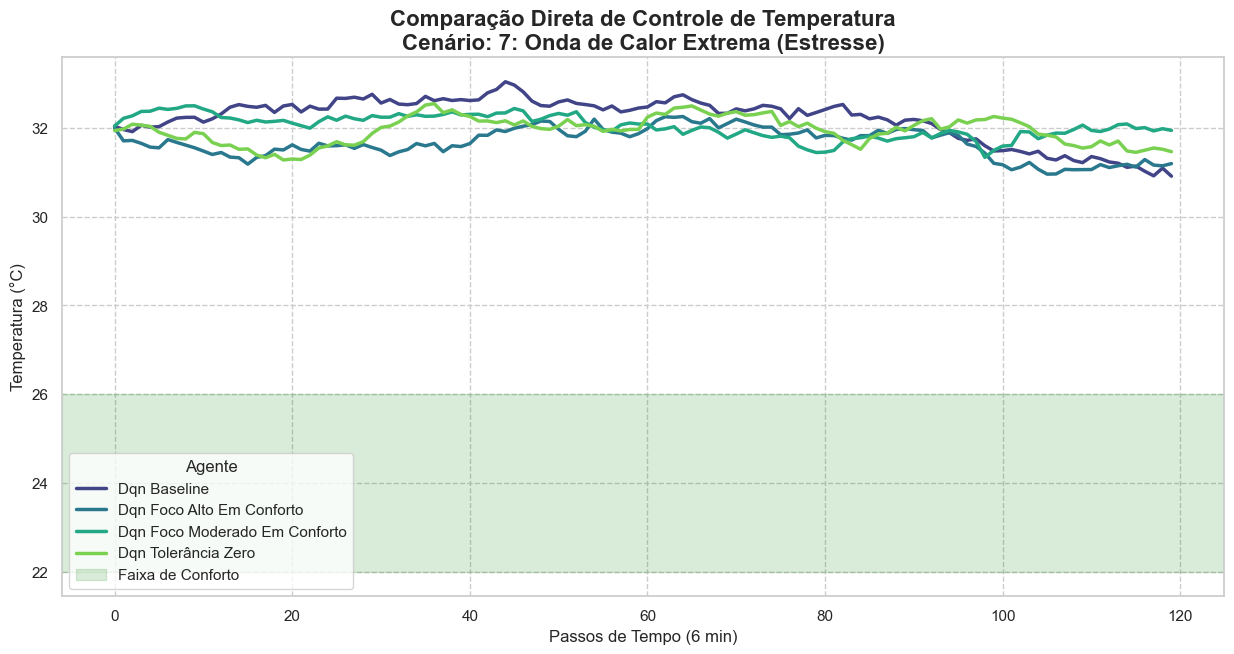

In [30]:
# Célula 9: Gráfico Comparativo de Temperatura (Versão Corrigida)

# --- CORREÇÃO: Adicionada verificação para garantir que as variáveis necessárias existem ---
if 'df_full' not in locals() or 'loaded_agents' not in locals() or not loaded_agents:
    print("ERRO: Execute a Célula 4 (e clique em 'Carregar Modelos') e a Célula 5 (agregação) antes de executar esta célula.")
else:
    # Seleciona os cenários mais interessantes para comparação direta
    scenarios_to_compare = [
        '3: Tarde Quente, Sala Cheia',
        '7: Onda de Calor Extrema (Estresse)'
    ]
    
    print("Gerando gráficos de comparação direta de temperatura...")
    for scenario in scenarios_to_compare:
        plt.figure(figsize=(15, 7))
        
        df_scenario = df_full[df_full['scenario'] == scenario]
        
        if df_scenario.empty:
            print(f"  -> Aviso: Nenhum dado encontrado para o cenário '{scenario}'. Pulando gráfico.")
            continue
        
        sns.lineplot(data=df_scenario, x='step', y='temperature', hue='agent', lw=2.5, palette='viridis')
        
        # Usa a configuração do primeiro agente carregado para a faixa de conforto
        # Esta linha agora é segura por causa da verificação inicial
        _, env_config, _ = list(loaded_agents.values())[0]
        plt.axhspan(env_config.temp_comfort_min, env_config.temp_comfort_max, color='green', alpha=0.15, label='Faixa de Conforto')
        
        plt.title(f'Comparação Direta de Controle de Temperatura\nCenário: {scenario}', fontsize=16, weight='bold')
        plt.ylabel('Temperatura (°C)')
        plt.xlabel('Passos de Tempo (6 min)')
        plt.legend(title='Agente')
        plt.grid(True, which='both', linestyle='--')
        plt.show()